In [1]:
import pandas as pd
from corrosions import PCM
from matplotlib import pyplot as plt

In [2]:
df = pd.read_excel(r"D:\Projects\corrosions\tests\normalize\pcm\excel\pcm-bgr-16-inch-jonggol-cimanggis-9-95-km-sequential-file.xlsx")
# df = pd.read_excel(r"D:\Projects\extract-kml\DATA IDDA24\Data CIPS\CIPS BGR 16 inch (Jonggol - Cimanggis 9.95 km).xlsx")

In [10]:
df.columns

Index(['Index', 'Start Symbol', 'Format', 'Version', 'PCMx Operating mode',
       'Locator Frequency', 'Alpha display', 'Depth (m)', 'Depth (ft)',
       'Depth to pipe center (m)', 'Depth to pipe center (ft)', 'dBuV',
       'Locate current A', '4 Hz Voltage phase', 'Signal strength',
       'Gain (dB)', 'MF Foot attached', '4Hz C-V Phase', '4Hz Current (A)',
       'Current 4-8Hz Phase', 'RTC day', 'RTC month', 'RTC year', 'UTC',
       'RTC Updated flag', 'Int GPS mode', 'Int GPS Latitude',
       'Int GPS Longitude', 'Int GPS Fix', 'Int GPS no. of satellites',
       'Int GPS dilution', 'Int GPS altitude', 'Ext GPS Latitude',
       'Ext GPS Longitude', 'Ext GPS Fix', 'Ext GPS no. of satellites',
       'Ext GPS dilution', 'Ext GPS altitude', 'Pipe Diameter',
       'Survey name (0-100)', 'Comment (0-100)', 'dbma', 'Distance',
       'Real Distance', 'Current Loss Rate', 'Direction'],
      dtype='object')

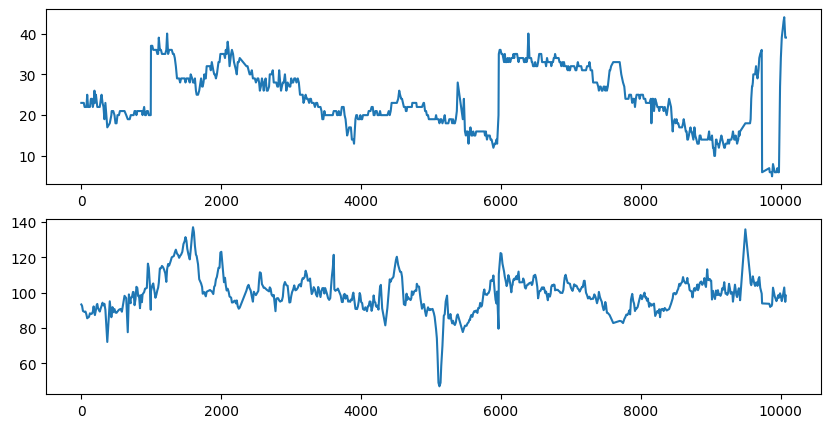

In [11]:
columns = ["Gain (dB)", "Int GPS altitude"]

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 5))

for index, column in enumerate(columns):
    axs[index].plot(df["Real Distance"], df[column])

In [3]:
def condition(voltage: float) -> str:
    """Get condition based on voltage.

    Args:
        voltage (float): voltage.

    Returns:
        str: condition.
    """
    print(type(voltage))
    if -1.2 < voltage <= -0.85:
        return "PROTECTED"
    if voltage <= -1.2:
        return "OVER PROTECTED"
    return "UNPROTECTED"

In [4]:
def transform_df(df: pd.DataFrame) -> pd.DataFrame:
    """Extract data from a file.

    Args:
        df (pd.DataFrame): data frame.

    Returns:
        pd.DataFrame: data extracted.
    """
    if "Off Voltage" in df.columns:
        # iccp - impress current cathodic protection
        df = df[
            [
                "Data No",
                "Off Voltage",
                "On Voltage",
                "Latitude",
                "Longitude",
                "Comment",
                "DCP/Feature/DCVG Anomaly",
            ]
        ].copy(deep=True)
        df["protection"] = "ICCP"
        df.rename(columns={"Off Voltage": "Voltage"}, inplace=True)
        return df

    # sacp - sacrificial anode cathodic protection
    df = df[
        [
            "Data No",
            "Voltage",
            "Latitude",
            "Longitude",
            "Comment",
            "DCP/Feature/DCVG Anomaly",
        ]
    ].copy(deep=True)
    df["On Voltage"] = None
    df["protection"] = "SACP"
    return df

In [5]:
df = transform_df(df)

In [6]:
df["Voltage"]

0      -0.74135
1      -0.54253
2      -0.80206
3      -0.75423
4      -0.37381
         ...   
3781   -0.88903
3782   -0.85929
3783   -0.85929
3784   -0.83354
3785   -0.82902
Name: Voltage, Length: 3786, dtype: float64

In [7]:
# df1 = df[
#     (df["Int GPS Latitude"] != 0)
#     & (df["Int GPS Longitude"] != 0)
#     & (df["4Hz Current (A)"] > 0.00)
# ]

In [8]:
# df1

In [9]:
pcm = PCM(
    file_or_dir=r"D:\Projects\extract-kml\DATA IDDA24\Data PCM\PCM CRB 4 inch (STD Kedawung - STD Gempol).xlsx",
    overwrite=True,
    verbose=True,
)

In [10]:
pcm.normalize()

Processing file: D:\Projects\extract-kml\DATA IDDA24\Data PCM\PCM CRB 4 inch (STD Kedawung - STD Gempol).xlsx
|| Processing sheet: Sequential Files OK!


In [11]:
pcm.results

[{'success': True,
  'message': 'File normalized',
  'excel': 'D:\\Projects\\corrosions\\normalize\\pcm\\excel\\pcm-crb-4-inch-std-kedawung-std-gempol-sequential-files.xlsx',
  'json': 'D:\\Projects\\corrosions\\normalize\\pcm\\json\\pcm-crb-4-inch-std-kedawung-std-gempol-sequential-files.json',
  'sheet': 'Sequential Files'}]

In [12]:
df = pd.DataFrame([{"a": None}, {"a": None}, {"a": None}, {"a": None}])

In [13]:
df["a"] * -1

0    NaN
1    NaN
2    NaN
3    NaN
Name: a, dtype: object